# DWR Outlier Detection Tests + Machine-Learning Ready Dataset

Five groups across multiple state and federal organizations monitor water quality and quantity through a network of instruments located within water bodies across California. [Here](https://cdec.water.ca.gov/webgis/?appid=cdecstation) is a map of all the instruments (select sensor type: other).

Currently, all five organizations implement different pipelines to read, process, store, and serve the data. We propose to create a prototype machine-learning ready dataset that demonstrates a unified pipeline to create a consistent, reproducible, and easily accessible datataset. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime as dt_obj
from IPython.display import display
 
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 3000)

In [2]:
# Confirm up-to-date version of numpy
np.__version__

'2.2.0'

## Data processing

To process the data, we will implement standardized outlier detection methods as outlined in the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit?usp=drive_link&ouid=112329730124000397523&rtpof=true&sd=true) guide. Group 3 includes suggested tests, which we can supplement with other ideas (e.g. [Talagala+2019](https://doi.org/10.1029/2019WR024906)). 

### Ingest sample data

In [3]:
def get_data_from_local_directory(filename, path):
    """
        Get data from a local directory.

        Parameters
        ----------
        filename : str
            Name of file to get from local directory.
        path : str
            Path to local directory.
        
        Returns
        -------
        df : pandas.DataFrame
            Dataframe containing data from local directory.
        
        Examples
        --------
        >>> get_data_from_local_directory('test.csv', 'data/')
    """
    file_with_path = path + filename
    df = pd.read_csv(file_with_path)
    
    return df

In [4]:
df = get_data_from_local_directory(filename='sample_data_BKS.csv', path='sample_data/')

In [5]:
df

,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE TIME,OBS DATE,VALUE,DATA_FLAG,UNITS
0,BKS,D,62,PH VAL,19890203 0000,19890203 0100,---,,PH
1,BKS,D,62,PH VAL,19890204 0000,19890204 0000,---,,PH
2,BKS,D,62,PH VAL,19890205 0000,19890205 0000,---,,PH
3,BKS,D,62,PH VAL,19890206 0000,19890206 0000,---,,PH
4,BKS,D,62,PH VAL,19890207 0000,19890207 0000,---,,PH
...,...,...,...,...,...,...,...,...,...
12914,BKS,D,62,PH VAL,20241207 0000,20241207 0000,7.4,,PH
12915,BKS,D,62,PH VAL,20241208 0000,20241208 0000,7.5,,PH
12916,BKS,D,62,PH VAL,20241209 0000,20241209 0000,7.5,,PH
12917,BKS,D,62,PH VAL,20241210 0000,20241210 0000,7.5,,PH


Convert all string values of '---' to `np.Nan`

In [6]:
df.replace(to_replace='---', value=np.nan, inplace=True)

Convert string values in `DATE TIME` column to datetime object and rename it `TIME`

In [7]:
df['TIME']=pd.to_datetime(df['DATE TIME'], format='%Y%m%d %H%M%S').reset_index(drop=True)

Convert all string values of numbers to ints for the column `VALUE`

In [8]:
df.VALUE = pd.to_numeric(df.VALUE)

Look at the max and min values for column `VALUE`:

In [9]:
np.nanmax(df.VALUE), np.nanmin(df.VALUE)

(np.float64(9.2), np.float64(3.7))

### Apply the basic gross range test

In [10]:
def gross_range_test(time_series, bounds):
    """
    Apply a gross range test to a time series.

    Parameters
    ----------
    time_series : pandas.Series
        The time series to be tested.


    Returns
    -------
    pandas.DataFrame
        The time series with flagged values outside the bounds.
    
    Examples
    --------
    ouasdfads

    """
    df = pd.DataFrame(time_series.copy())
    if df.empty:
        raise ValueError('No input data.')
    if not all(bounds):
        raise ValueError('One of all of the bounds is empty.')
    df['Flag'] = np.where(((df > bounds[1]) | ((df <= bounds[0]))), 0, 1) 
    return df

In [11]:
df_out = gross_range_test(time_series=df.VALUE, bounds=[4,8])

In [12]:
df_out ['TIME'] = df['TIME']

<Axes: xlabel='TIME', ylabel='VALUE'>

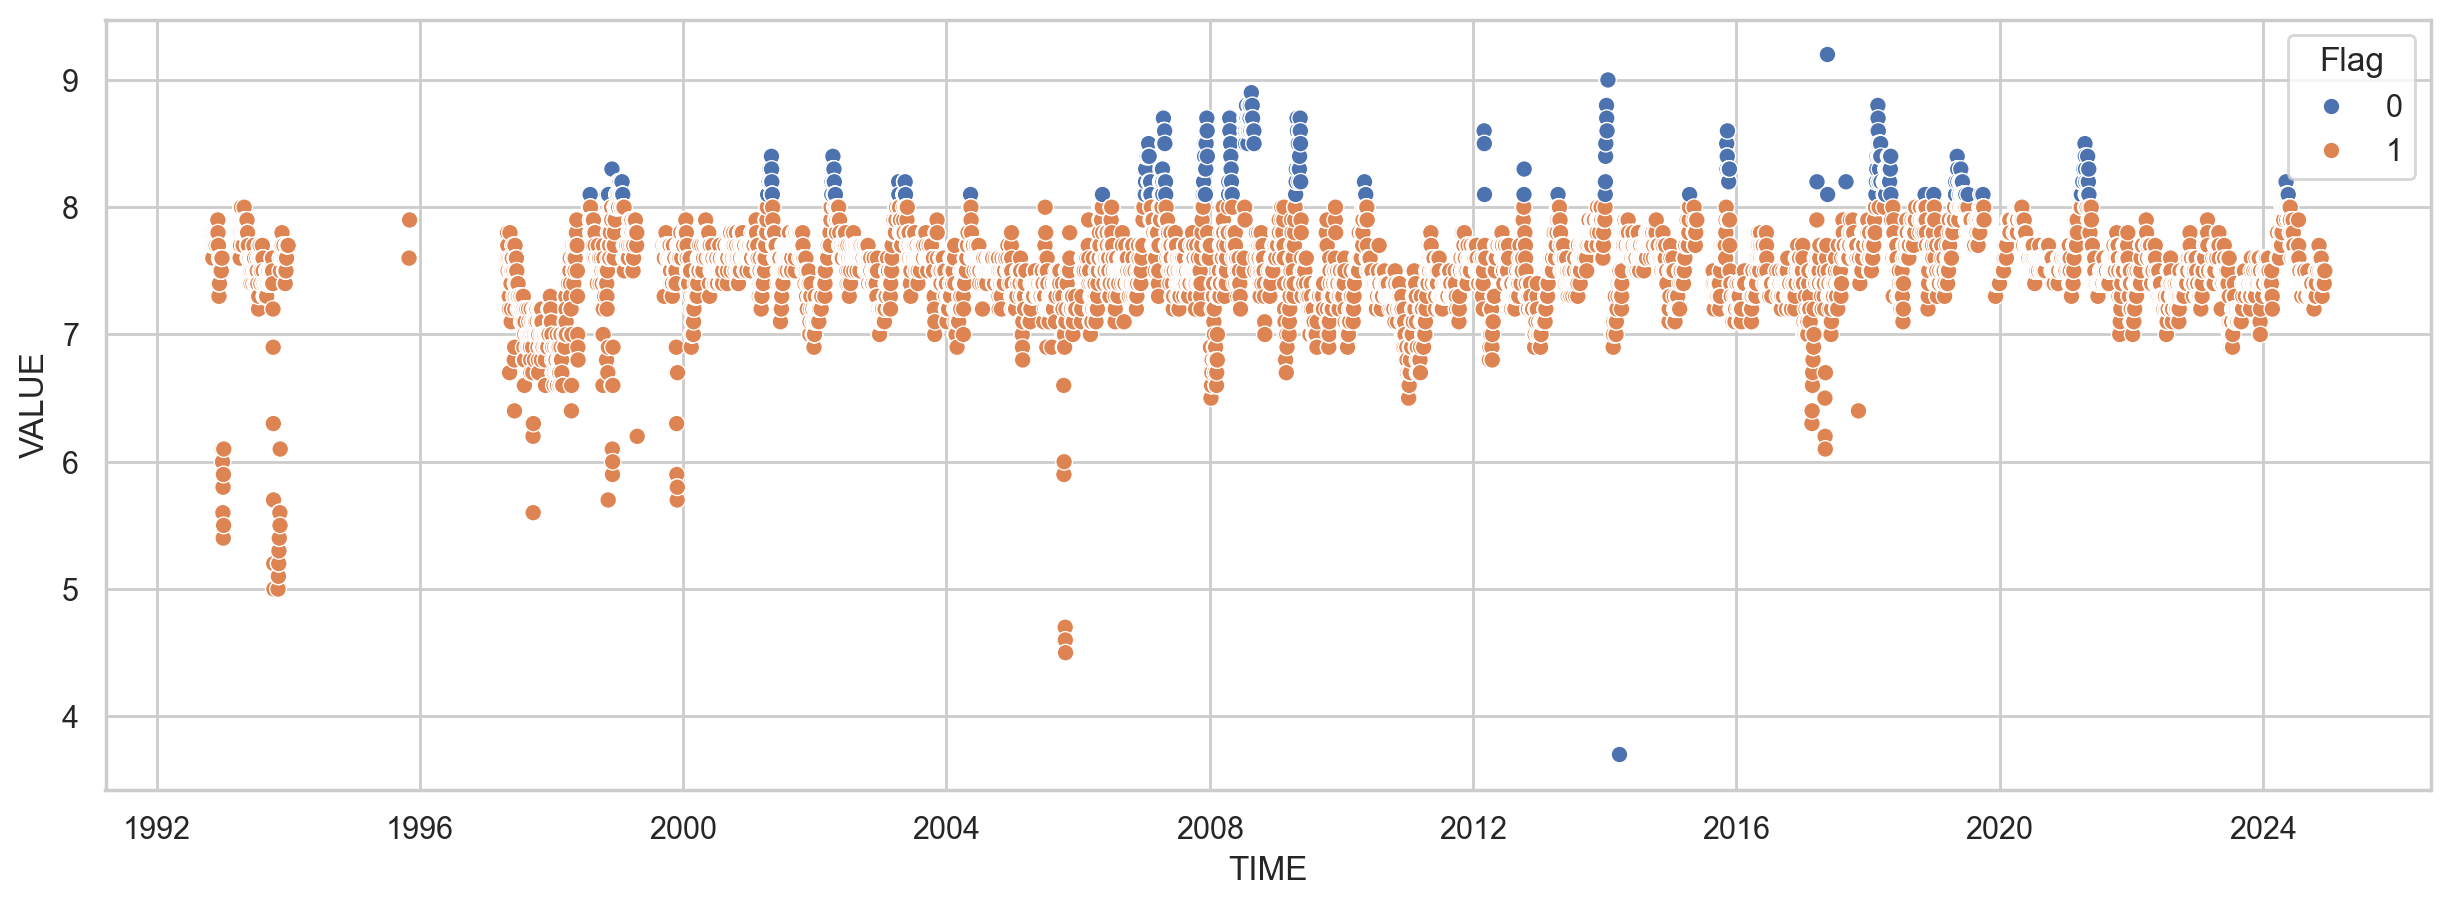

In [13]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_out, x='TIME', y='VALUE', hue='Flag')